Description:

This code uses the Prophet model to predict monthly revenue (line_total) for March to December 2018 based on historical sales data from January 2014 to February 2018. First, the sales data is loaded and aggregated by month, and a datetime column is created for Prophet. The data is then formatted with ds as the date and y as the revenue value. A Prophet model is initialized with yearly seasonality and fitted to the historical monthly revenue. Future dates for March to December 2018 are generated, and the model predicts revenue for these months, producing both the predicted values (yhat) and confidence intervals (yhat_lower and yhat_upper). Finally, the predicted revenue is visualized in a line chart with confidence intervals, allowing analysis of expected sales trends and seasonality patterns for the remaining months of 2018.

In [1]:
# Install Prophet library
!pip install prophet

In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet


In [3]:
# Load sales data from GitHub
base_url = "https://raw.githubusercontent.com/Ilseemerich5/Retail-Sales-Performance-Analysis-with-Python-Power-BI-and-SQL/main/"
sales_orders = pd.read_csv(
    base_url + "sales_orders_transformed.csv",
    sep=';',
    parse_dates=['order_date'],
    dayfirst=True,
    dtype={
        'order_quantity': 'float64',
        'unit_price': 'float64',
        'line_total': 'float64',
        'total_unit_cost': 'float64',
        'profit': 'float64',
        'profit_margin': 'float64'
    }
)

# Show first rows
sales_orders.head()


,order_number,order_date,customer_name_index,channel,currency_code,warehouse_code,delivery_region_index,product_description_index,order_quantity,unit_price,line_total,total_unit_cost,profit,profit_margin
0,SO - 0002010,2014-01-01,109,Distributor,USD,NXH382,594,11,11.0,1045.2,11497.2,543.50,501.70,0.48
1,SO - 0002504,2014-01-01,42,Export,USD,FLR025,829,27,11.0,1976.5,21741.5,790.60,1185.90,0.60
2,SO - 0009931,2014-01-01,83,Wholesale,USD,AXW291,19,13,6.0,6525.8,39154.8,3589.19,2936.61,0.45
3,SO - 0009346,2014-01-01,132,Wholesale,USD,NXH382,210,13,7.0,1011.7,7081.9,839.71,171.99,0.17
4,SO - 0002468,2014-01-01,19,Wholesale,USD,GUT930,74,5,8.0,1983.2,15865.6,1348.58,634.62,0.32


In [4]:
# Create year and month columns
sales_orders['year'] = sales_orders['order_date'].dt.year
sales_orders['month'] = sales_orders['order_date'].dt.month

# Aggregate revenue (line_total) by year and month
monthly_sales = sales_orders.groupby(['year', 'month'])['line_total'].sum().reset_index()
monthly_sales.rename(columns={'line_total':'revenue'}, inplace=True)

# Show first rows
monthly_sales.head()


,year,month,revenue
0,2014,1,25020272.3
1,2014,2,23882719.5
2,2014,3,23709035.4
3,2014,4,24853382.0
4,2014,5,25662165.8


In [5]:
# Prophet requires columns: ds (date) and y (value)
# Create a datetime column for the first day of each month
monthly_sales['ds'] = pd.to_datetime(monthly_sales[['year', 'month']].assign(day=1))
monthly_sales['y'] = monthly_sales['revenue']

# Keep only the columns Prophet needs
df = monthly_sales[['ds','y']]

# Show first rows
df.head()

,ds,y
0,2014-01-01,25020272.3
1,2014-02-01,23882719.5
2,2014-03-01,23709035.4
3,2014-04-01,24853382.0
4,2014-05-01,25662165.8


In [6]:
# Initialize Prophet model with yearly seasonality
model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)

# Fit the model to historical monthly revenue data
model.fit(df)


DEBUG:cmdstanpy:input tempfile: /tmp/tmp0mor9sja/5nk91b_x.json
DEBUG:cmdstanpy:input tempfile: /tmp/tmp0mor9sja/9j03g9ej.json
DEBUG:cmdstanpy:idx 0
DEBUG:cmdstanpy:running CmdStan, num_threads: None
DEBUG:cmdstanpy:CmdStan args: ['/usr/local/lib/python3.12/dist-packages/prophet/stan_model/prophet_model.bin', 'random', 'seed=87214', 'data', 'file=/tmp/tmp0mor9sja/5nk91b_x.json', 'init=/tmp/tmp0mor9sja/9j03g9ej.json', 'output', 'file=/tmp/tmp0mor9sja/prophet_modelljp3zxa4/prophet_model-20251021203921.csv', 'method=optimize', 'algorithm=newton', 'iter=10000']
20:39:21 - cmdstanpy - INFO - Chain [1] start processing
INFO:cmdstanpy:Chain [1] start processing
20:39:22 - cmdstanpy - INFO - Chain [1] done processing
INFO:cmdstanpy:Chain [1] done processing


In [7]:
# Define future dates: March to December 2018
future_dates = pd.date_range(start='2018-03-01', end='2018-12-01', freq='MS')
future_df = pd.DataFrame({'ds': future_dates})

# Show future dates
future_df.head()

,ds
0,2018-03-01
1,2018-04-01
2,2018-05-01
3,2018-06-01
4,2018-07-01


In [8]:
# Use the trained model to predict revenue for future dates
forecast = model.predict(future_df)

# Show relevant columns: ds (date), yhat (predicted), yhat_lower, yhat_upper
forecast[['ds','yhat','yhat_lower','yhat_upper']]

# ds: the date of each month (March–December 2018)
# yhat: the predicted revenue
# yhat_lower and yhat_upper: the prediction confidence interval

,ds,yhat,yhat_lower,yhat_upper
0,2018-03-01,2.455590e+07,2.392279e+07,2.523200e+07
1,2018-04-01,2.382161e+07,2.320323e+07,2.447336e+07
2,2018-05-01,2.536620e+07,2.473595e+07,2.603704e+07
3,2018-06-01,2.404587e+07,2.337126e+07,2.472905e+07
4,2018-07-01,2.409423e+07,2.345982e+07,2.471962e+07
5,2018-08-01,2.544594e+07,2.482442e+07,2.611417e+07
6,2018-09-01,2.466255e+07,2.403837e+07,2.529267e+07
7,2018-10-01,2.484341e+07,2.420801e+07,2.546782e+07
8,2018-11-01,2.519407e+07,2.458547e+07,2.590564e+07
9,2018-12-01,2.514796e+07,2.447820e+07,2.577435e+07


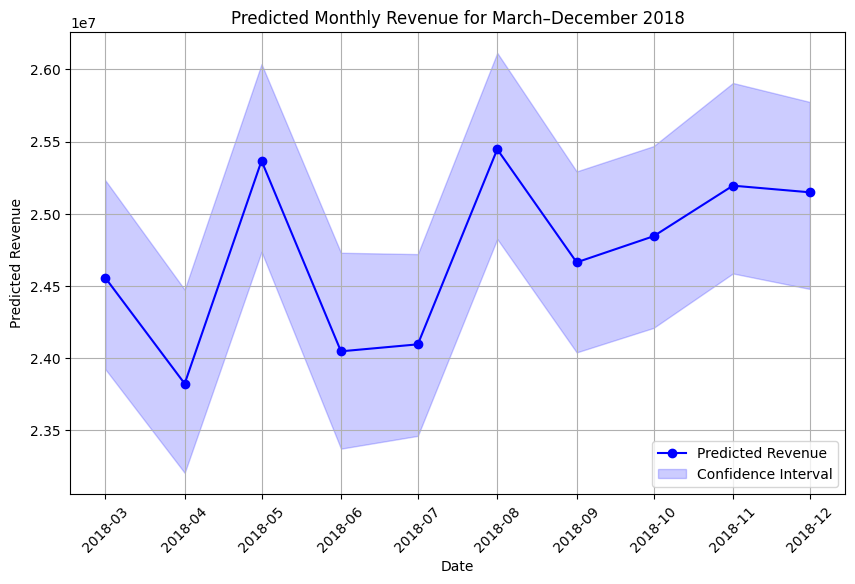

In [9]:
# Plot predicted monthly revenue for March–December 2018
plt.figure(figsize=(10,6))

plt.plot(forecast['ds'], forecast['yhat'], marker='o', linestyle='-', color='blue', label='Predicted Revenue')
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='blue', alpha=0.2, label='Confidence Interval')

plt.xlabel('Date')
plt.ylabel('Predicted Revenue')
plt.title('Predicted Monthly Revenue for March–December 2018')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

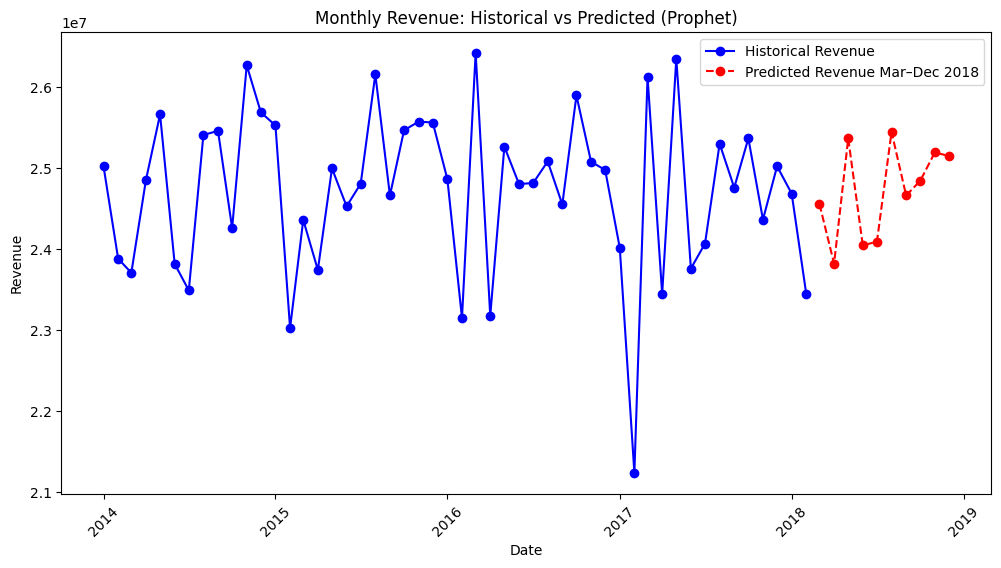

In [10]:
# Plot historical revenue and predicted revenue using Prophet
plt.figure(figsize=(12,6))

# Historical revenue
plt.plot(monthly_sales['ds'], monthly_sales['y'], label='Historical Revenue', color='blue', marker='o')

# Predicted revenue (March–December 2018)
plt.plot(forecast['ds'], forecast['yhat'], label='Predicted Revenue Mar–Dec 2018', linestyle='--', color='red', marker='o')

plt.xlabel('Date')
plt.ylabel('Revenue')
plt.title('Monthly Revenue: Historical vs Predicted (Prophet)')
plt.legend()
plt.xticks(rotation=45)
plt


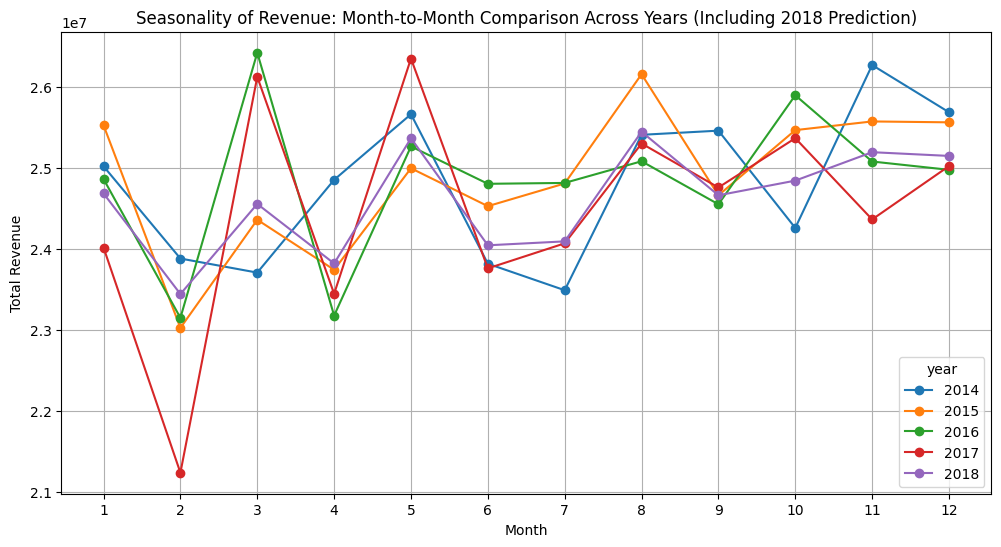

In [11]:
# Create year and month columns in the original data
sales_orders['year'] = sales_orders['order_date'].dt.year
sales_orders['month'] = sales_orders['order_date'].dt.month

# Aggregate historical monthly revenue
monthly_sales_hist = sales_orders.groupby(['year', 'month'])['line_total'].sum().reset_index()
monthly_sales_hist.rename(columns={'line_total':'revenue'}, inplace=True)

# Prepare predicted 2018 revenue for plotting from Prophet
future_df_plot = forecast.copy()
future_df_plot['year'] = future_df_plot['ds'].dt.year
future_df_plot['month'] = future_df_plot['ds'].dt.month
future_df_plot = future_df_plot[['year', 'month', 'yhat']]  # Use Prophet's prediction
future_df_plot.rename(columns={'yhat':'revenue'}, inplace=True)

# Combine historical and predicted revenue
all_revenue = pd.concat([monthly_sales_hist, future_df_plot], ignore_index=True)

# Create pivot table: months as rows, years as columns
pivot_revenue = all_revenue.pivot(index='month', columns='year', values='revenue').sort_index()

# Plot all years together
pivot_revenue.plot(figsize=(12,6), marker='o')
plt.xticks(range(1,13))
plt.xlabel('Month')
plt.ylabel('Total Revenue')
plt.title('Seasonality of Revenue: Month-to-Month Comparison Across Years (Including 2018 Prediction)')
plt.grid(True)
plt.show()
